Code for reading PLE maps, correct them by Baseline and Intensity and also find peaks and compare peaks

Data - PLE maps from Annika

In [2]:
import originpro as op
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


file = r"H:\FUBerlin\Measurements\PLE\AnnikaM\20260504_FormicAcid_Water_NoPos\2026_05_04_DifferentWaterFormicAcidRatiosSimplified.opju"
op.open(file)
for obj in op.pages():
    if type(obj).__name__ == "WBook":
        print("BOOK:", obj.name)
        for sheet in obj:
            print("   PAGE:", sheet.name)



def get_book(book_name):
    for x in op.pages():
        if type(x).__name__ == "WBook" and x.name == book_name:
            return x
    
    raise ValueError(f"Workbook '{book_name}' not found")


def plot_ple(PLE, vmin=None, vmax=None):
    plt.pcolormesh(
    PLE.columns,
    PLE.index,
    PLE.values,
    shading='auto',
    cmap='viridis',
    )
    plt.xlabel("Emission wavelength (nm)")
    plt.ylabel("Excitation wavelength (nm)")
    plt.colorbar(label="Intensity (a.u.)")
    plt.show()


BOOK: FAH2ON1
   PAGE: Graph_S1
   PAGE: Contour_S1
   PAGE: Data_S1
   PAGE: Data_R1
   PAGE: XYZ_S1
   PAGE: Note
BOOK: FAH2ON2
   PAGE: Graph_S1
   PAGE: Contour_S1
   PAGE: Data_S1
   PAGE: Data_R1
   PAGE: XYZ_S1
   PAGE: Note
BOOK: FANoPo4
   PAGE: Graph_S1
   PAGE: Contour_S1
   PAGE: Data_S1
   PAGE: Data_R1
   PAGE: XYZ_S1
   PAGE: Note
BOOK: FANoPo3
   PAGE: Graph_S1
   PAGE: Contour_S1
   PAGE: Data_S1
   PAGE: Data_R1
   PAGE: XYZ_S1
   PAGE: Note
BOOK: RefENo1
   PAGE: Graph_S1
   PAGE: Contour_S1
   PAGE: Data_S1
   PAGE: Data_R1
   PAGE: XYZ_S1
   PAGE: Note
BOOK: FANoPo2
   PAGE: Graph_S1
   PAGE: Contour_S1
   PAGE: Data_S1
   PAGE: Data_R1
   PAGE: XYZ_S1
   PAGE: Note
BOOK: RefH2O13
   PAGE: Graph_S1
   PAGE: Contour_S1
   PAGE: Data_S1
   PAGE: Data_R1
   PAGE: XYZ_S1
   PAGE: Note
BOOK: FANoPo9
   PAGE: Graph_S1
   PAGE: Contour_S1
   PAGE: Data_S1
   PAGE: Data_R1
   PAGE: XYZ_S1
   PAGE: Note
BOOK: RefH2O12
   PAGE: Graph_S1
   PAGE: Contour_S1
   PAGE: Data_S1
 

Workbook: FAH2ON1
Workbook: FAH2ON2
Workbook: FANoPo4
Workbook: FANoPo3
Workbook: RefENo1
Workbook: FANoPo2
Workbook: RefH2O13
Workbook: FANoPo9
Workbook: RefH2O12


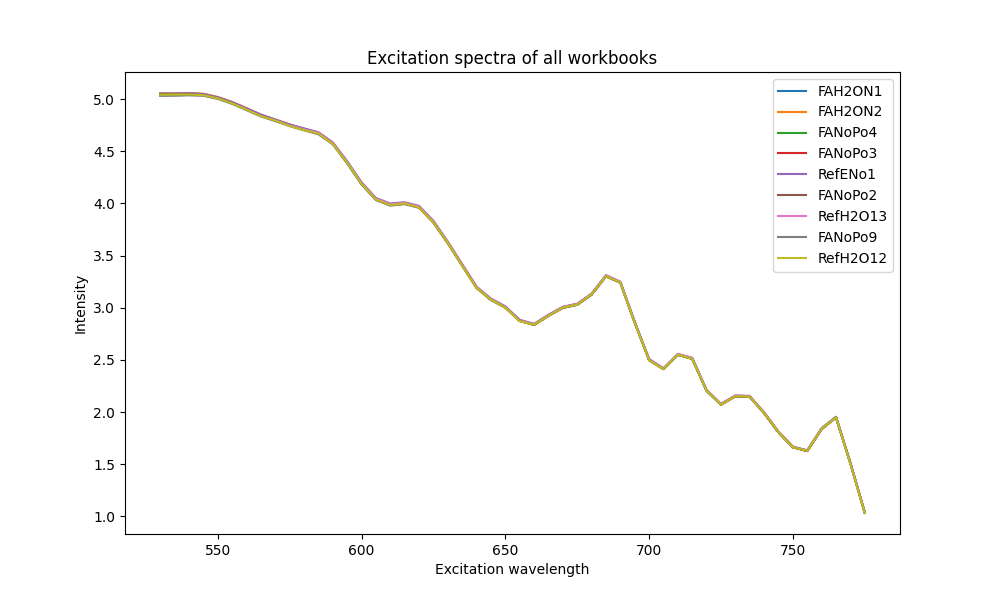

In [3]:
import matplotlib.pyplot as plt

# Get all workbooks
books = [x for x in op.pages() if type(x).__name__ == "WBook"]

# Loop through all workbooks
spectra = {}

plt.figure(figsize=(10, 6))

for book in books:
    print(f"Workbook: {book.name}")

    # Get pages in this workbook
    pages = {page.name: page for page in book}

    # Choose the data page (change name if needed)
    if "Data_R1" not in pages:
        print(f"Skipping {book.name}: Data_R1 not found")
        continue

    Ref = pages["Data_R1"]

    # Convert to dataframe
    df = Ref.to_df().T
    df = df.reset_index()
    df = df[1:]
    df.columns = ['Exc', 'Int']
    df = df.astype(float)

    # Store dataframe
    spectra[book.name] = df.set_index("Exc")

    # Plot
    plt.plot(df.Exc, df.Int, label=book.name)

plt.xlabel("Excitation wavelength")
plt.ylabel("Intensity")
plt.title("Excitation spectra of all workbooks")
plt.legend()
plt.show()

#### Defining structure of a Workbook or Measurement

* name: given during measurement
* pages: fields of the measurement (Data_S1, Data_S1c, XYZ, Data_R1,...)

* XYZ: Dataframe built based on the 3 columns to built the matix
* PLE_WL: PLE reconstructed in wavelenght scale
* PLE_E: PLE reconstructed in energy scale

In [4]:
from dataclasses import dataclass, field

@dataclass
class Measurement:
    name: str
    pages: dict = field(default_factory=dict)

    label: str = None
    Note: object = None

    PLE_WL: object = None
    PLE_E: object = None
    R1: object = None

    PLE_corrected: object = None

    peaks: object = None

    time: float = None

    def __post_init__(self):
        if self.label is None:
            self.label = self.name

In [5]:
measurements = {}

books = [x for x in op.pages() if type(x).__name__ == "WBook"]

hc = 1239.84193  # eV·nm

for book in books:

    print("Processing:", book.name)

    pages = {page.name: page for page in book}

    measurement = Measurement(
        name=book.name,
        pages=pages,
        Note=pages["Note"].to_df().iloc[0,0]
    )


    # ==========================
    # Extract R1 excitation profile
    # ==========================
    if "Data_R1" in pages:

        try:
            Ref = pages["Data_R1"]

            df_R1 = Ref.to_df().T
            df_R1 = df_R1.reset_index()
            df_R1 = df_R1[1:]

            df_R1.columns = ['Exc', 'Int']
            df_R1 = df_R1.astype(float)

            measurement.R1 = df_R1.set_index("Exc")

        except Exception as e:
            print(f"Could not extract R1 for {book.name}: {e}")


    # ==========================
    # Extract PLE
    # ==========================
    if "XYZ_S1" in pages:

        try:
            df_xyz = pages["XYZ_S1"].to_df()

            df_xyz.columns = ['Em', 'Exc', 'Int']
            df_xyz = df_xyz.astype(float)

            df_xyz["Em_Energy"] = hc / df_xyz["Em"]
            df_xyz["Exc_Energy"] = hc / df_xyz["Exc"]

            measurement.XYZ_df = df_xyz

            measurement.PLE_WL = df_xyz.pivot(
                index="Exc",
                columns="Em",
                values="Int"
            )

            measurement.PLE_E = df_xyz.pivot(
                index="Exc_Energy",
                columns="Em_Energy",
                values="Int"
            )

        except Exception as e:
            print(f"Could not create PLE for {book.name}: {e}")


    measurements[book.name] = measurement

Processing: FAH2ON1
Processing: FAH2ON2
Processing: FANoPo4
Processing: FANoPo3
Processing: RefENo1
Processing: FANoPo2
Processing: RefH2O13
Processing: FANoPo9
Processing: RefH2O12


In [6]:
NoPo_1s = measurements["RefH2O12"]              #RefH2ONoPo1s   1s      Step5   Slits10
NoPo_5s = measurements["RefENo1"]               #RefENoPo5s     5s      Step5   Slits10

H2O = measurements["RefH2O13"]                  #RefH2O10s      10s     Step5   Slits10

FAH2O_NopoBSa = measurements["FAH2ON1"]         #FAH2ONoPoBS    10s     Step5   Slits10
FAH2O_NopoBSb = measurements["FAH2ON2"]         #FAH2ONoPoBS    10s     Step5   Slits10

FA_NoPoTS = measurements["FANoPo3"]             #FANoPoTS       10s     Step5   Slits10

FA_NoPoBS_1s = measurements["FANoPo4"]          #FANoPoBS       1s      Step5   Slits10
FA_NoPoBS_10s = measurements["FANoPo2"]         #FANoPoBS       10s     Step5   Slits10
FA_NoPoBS_20s = measurements["FANoPo9"]         #FANoPoBS       20s     Step5   Slits10

####display(Markdown(FA_NoPo9.Note))

In [7]:
NoPo_1s.time = 1.0
NoPo_5s.time = 5.0
H2O.time = 10.0
FAH2O_NopoBSa.time = 10.0
FAH2O_NopoBSb.time = 10.0
FA_NoPoTS.time = 10.0
FA_NoPoBS_1s.time = 1.0
FA_NoPoBS_10s.time = 10.0
FA_NoPoBS_20s.time = 20.0



NoPo_1s.label = 'NoPo_1s'
NoPo_5s.label ='NoPo_5s'
H2O.label = 'H2O'
FAH2O_NopoBSa.label = 'FAH2O_NopoBSa'
FAH2O_NopoBSb.label = 'FAH2O_NopoBSb'
FA_NoPoTS.label = 'FA_NoPoTS'
FA_NoPoBS_1s.label ='FA_NoPoBS_1s' 
FA_NoPoBS_10s.label = 'FA_NoPoBS_10s'
FA_NoPoBS_20s.label = 'FA_NoPoBS_20s'

Alles = [NoPo_1s,
        NoPo_5s,
        H2O,
        FAH2O_NopoBSa,
        FAH2O_NopoBSb,
        FA_NoPoTS,
        FA_NoPoBS_1s,
        FA_NoPoBS_10s,
        FA_NoPoBS_20s]

### Plot all

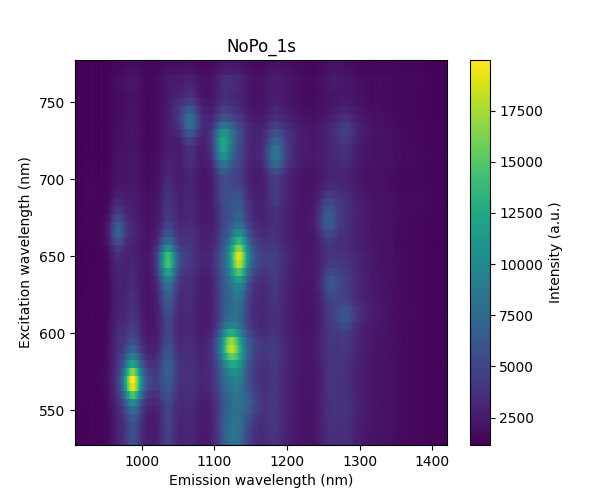

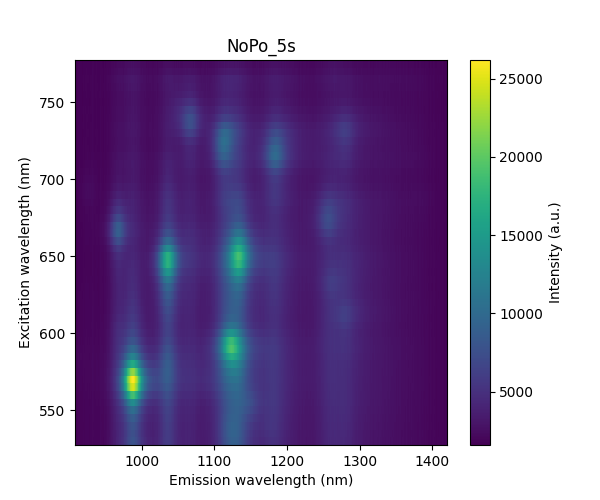

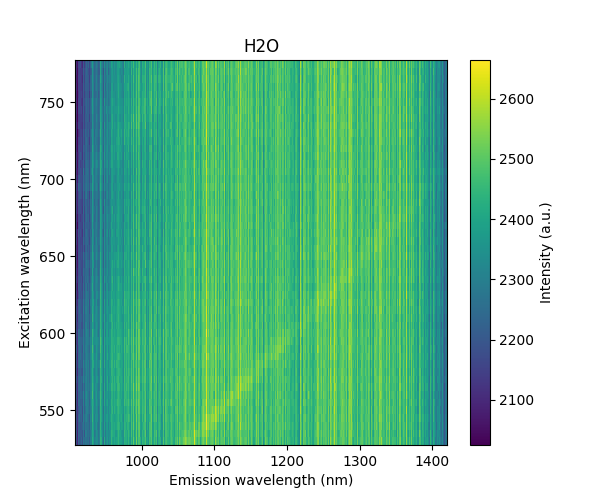

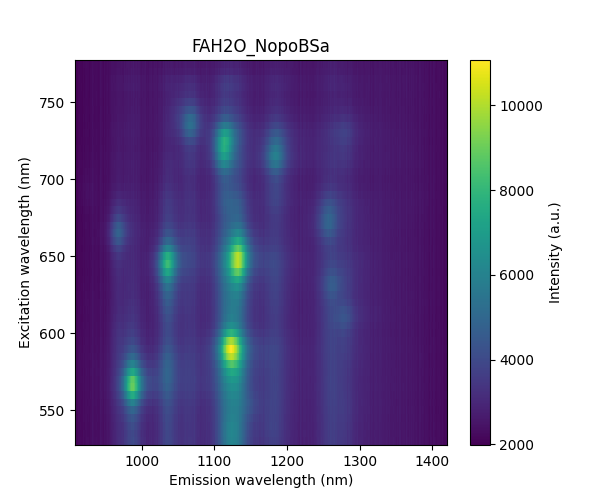

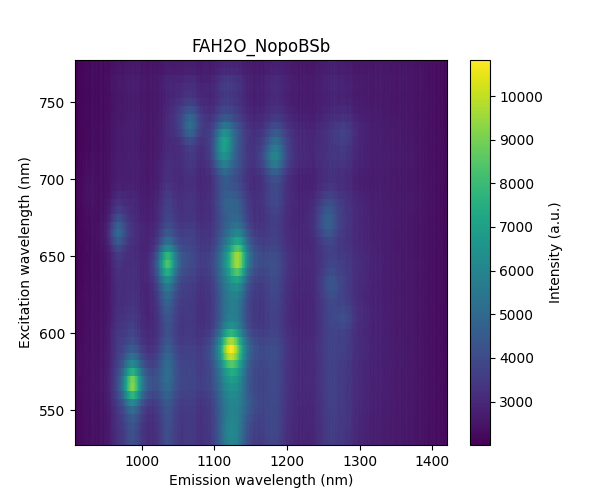

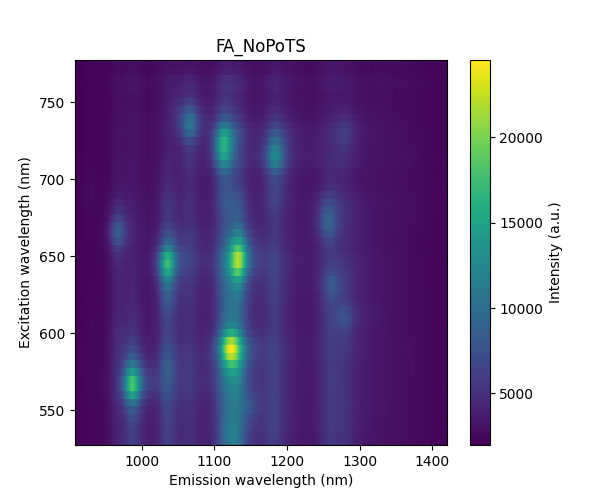

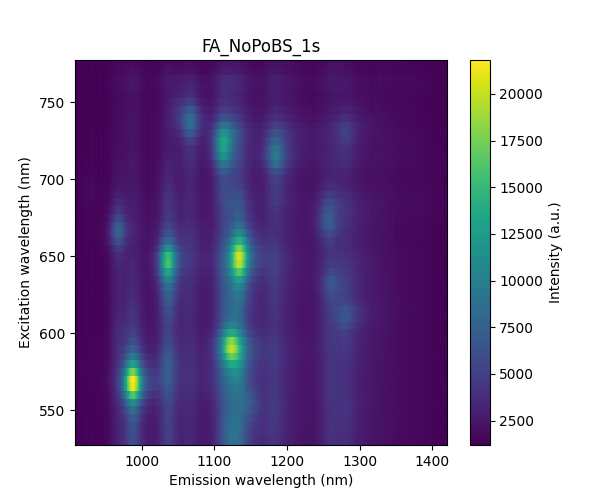

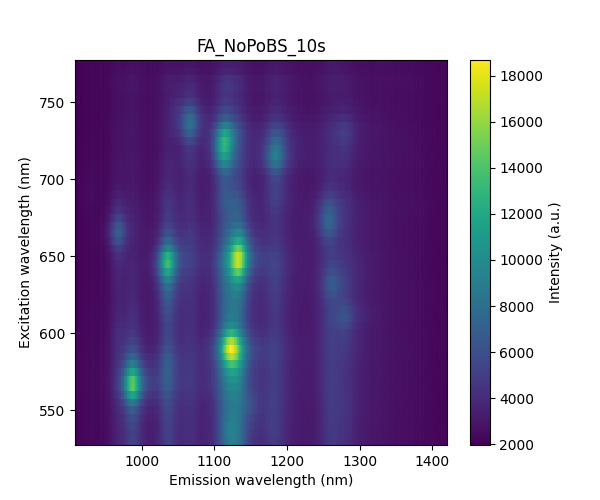

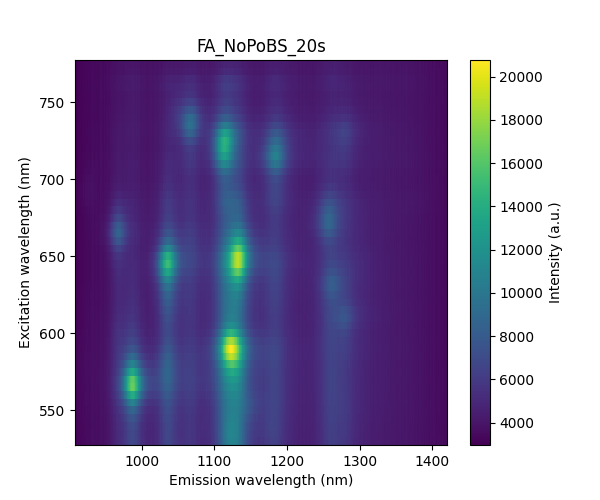

In [8]:
for SPECTRUM in Alles:

    PLE = SPECTRUM.PLE_WL

    plt.figure(figsize=(6, 5))

    plt.pcolormesh(
        PLE.columns,
        PLE.index,
        PLE.values,
        shading='auto',
        cmap='viridis',
    )

    plt.xlabel("Emission wavelength (nm)")
    plt.ylabel("Excitation wavelength (nm)")
    plt.colorbar(label="Intensity (a.u.)")
    plt.title(SPECTRUM.label)

    plt.show()

### Correct all

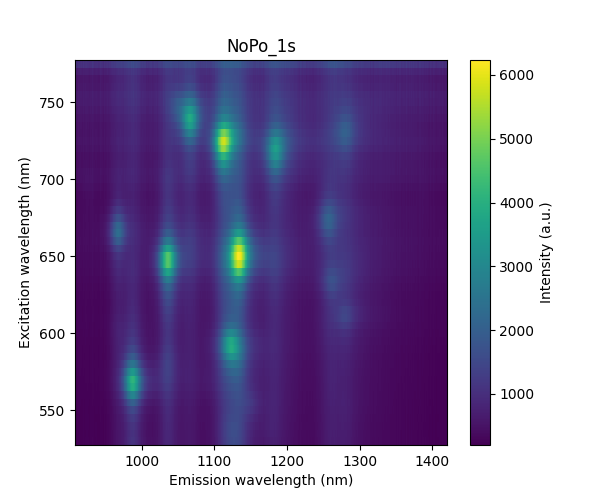

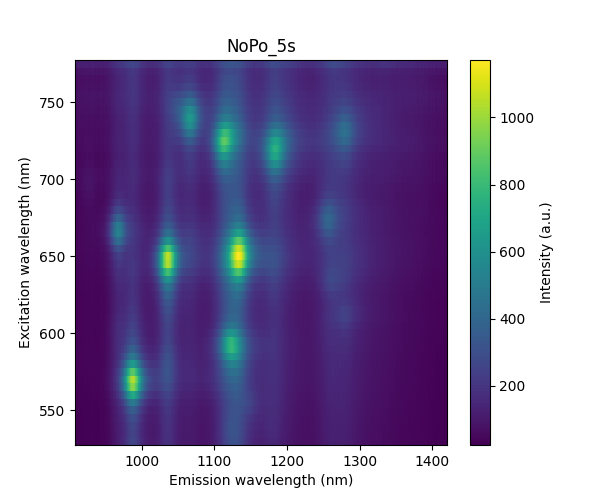

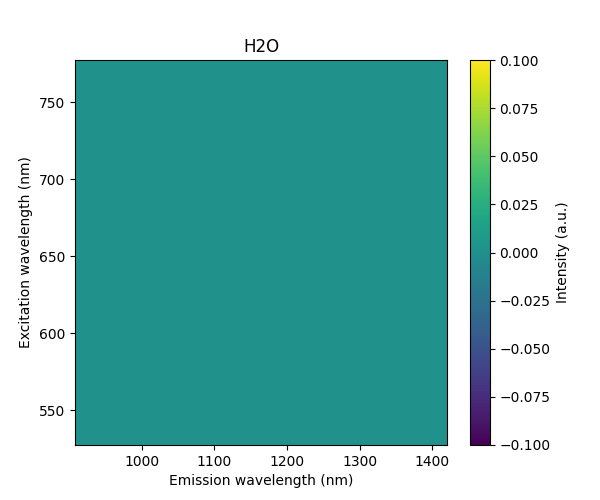

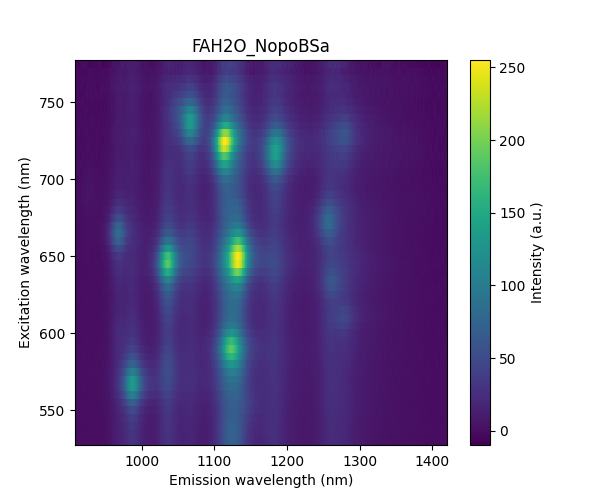

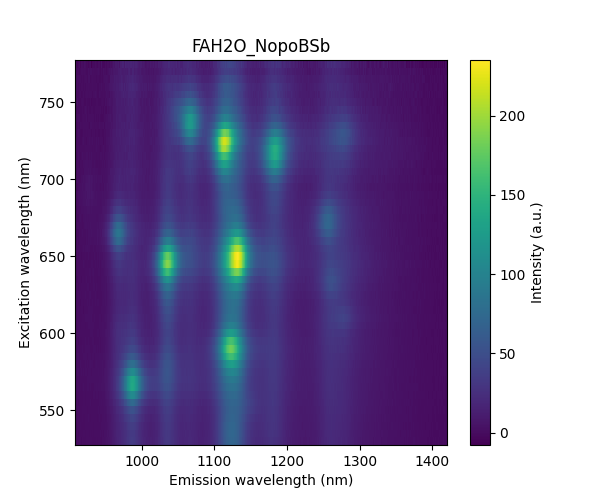

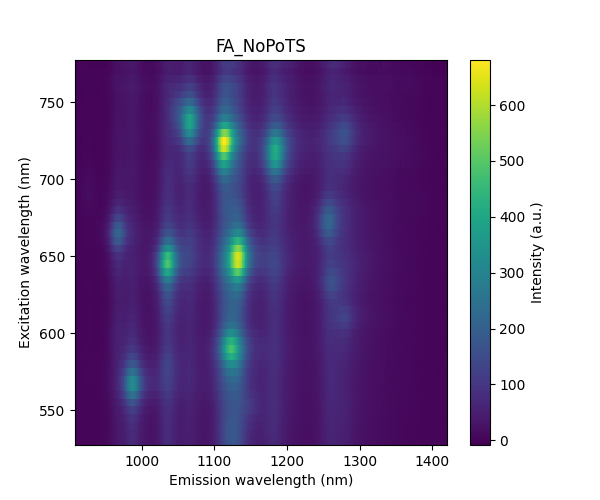

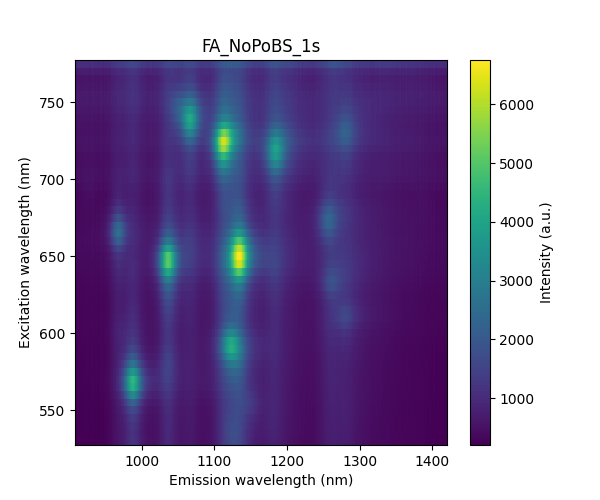

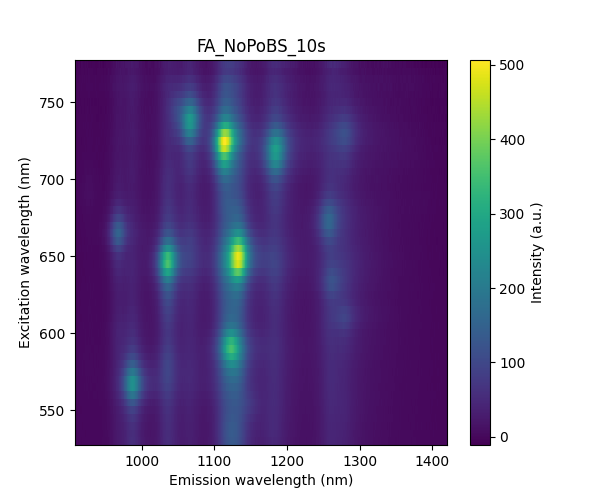

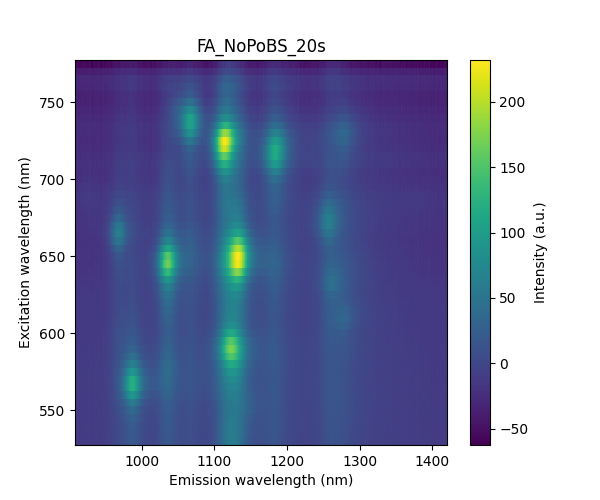

In [9]:
Water_Correction = H2O.PLE_WL.div(H2O.R1.Int, axis=0)/H2O.time

for SPECTRUM in Alles:

    PLE = SPECTRUM.PLE_WL.div(SPECTRUM.R1.Int, axis=0)/SPECTRUM.time - Water_Correction

    plt.figure(figsize=(6, 5))

    plt.pcolormesh(
        PLE.columns,
        PLE.index,
        PLE.values,
        shading='auto',
        cmap='viridis',
    )

    plt.xlabel("Emission wavelength (nm)")
    plt.ylabel("Excitation wavelength (nm)")
    plt.colorbar(label="Intensity (a.u.)")
    plt.title(SPECTRUM.label)
    plt.show()

    SPECTRUM.PLE_corrected = PLE

In [10]:
import matplotlib.pyplot as plt

def plot_PLEMAP(PLESpectrum, label = 'Map', scale="WL", cmap="viridis", vmin=None, vmax=None):
  
    if PLESpectrum is None:
        print(f"No PLE map available")
        return


    plt.figure(figsize=(6, 5))

    plt.pcolormesh(
        PLESpectrum.columns,
        PLESpectrum.index,
        PLESpectrum.values,
        shading="auto",
        cmap=cmap,
        vmin=vmin,
        vmax=vmax
    )

    plt.xlabel('Emission')
    plt.ylabel('Excitation')
    plt.colorbar(label=label)

    plt.tight_layout()
    plt.show()

In [11]:
#NoPo_1s,
#NoPo_5s,

#H2O,

#FAH2O_NopoBSa,
#FAH2O_NopoBSb,

#FA_NoPoTS,

#FA_NoPoBS_1s,
#FA_NoPoBS_10s,
#FA_NoPoBS_20s



In [12]:
FAH2O_NopoBSa

Measurement(name='FAH2ON1', pages={'Graph_S1': WSheet: [FAH2ON1]Graph_S1, 'Contour_S1': WSheet: [FAH2ON1]Contour_S1, 'Data_S1': WSheet: [FAH2ON1]Data_S1, 'Data_R1': WSheet: [FAH2ON1]Data_R1, 'XYZ_S1': WSheet: [FAH2ON1]XYZ_S1, 'Note': WSheet: [FAH2ON1]Note}, label='FAH2O_NopoBSa', Note='[EXP_FD_FILE]\r\nEXPERIMENT SUMMARY:\r\nExperiment Type: 3D Acquisition[Excitation vs Emission vs Intensity]\r\nExperiment Comment: 3D Acquisition[Excitation vs Emission vs Intensity]\r\nRayleigh Masking 1st Order Enable: False\r\nRayleigh Masking 2nd Order Enable: False\r\nRayleigh Masking Slit Width: 0.000000\r\n\r\n\r\nGENERAL PARAMETERS:\r\nData Identifier: FAH2ONoPoBS\r\nNumber of Data Points: 12845056\r\nIntegration Time: 10.000000s\r\n\r\nEM1: IHR 320 (Mono1)\r\nSide Entrance Slit: 10.00 nmBandpass \r\nGrating: Density 150 (Blaze: 1200)\r\nStart: 1166.01nm\r\nEnd: 1166.01nm\r\n\r\nEX1: Excitation 1 (Mono2)\r\nStart: 530.00nm\r\nEnd: 775.00nm\r\nIncrement: 5.00nm\r\nSide Entrance Slit: 10.00 nmBand

In [13]:
import numpy as np
from scipy.ndimage import maximum_filter
from scipy.optimize import curve_fit


def gaussian2D(coords, A, x0, y0, sx, sy, B):

    x, y = coords

    return (
        A *
        np.exp(
            -(
                ((x-x0)**2)/(2*sx**2)
                +
                ((y-y0)**2)/(2*sy**2)
            )
        )
        + B
    ).ravel()



def find_PLE_peaks(
        SPECTRUM,
        threshold=0.2,
        min_distance=10,
        n_peaks=10,
        fit_size=5):

    PLE = SPECTRUM.PLE_corrected

    data = PLE.values

    # normalize
    data_norm = data / np.nanmax(data)


    # --------
    # Find candidates
    # --------

    local_max = maximum_filter(
        data_norm,
        size=min_distance
    ) == data_norm

    candidates = local_max & (data_norm > threshold)

    rows, cols = np.where(candidates)


    peaks = []


    # --------
    # Fit every peak
    # --------

    for r,c in zip(rows,cols):

        # avoid edges
        if (
            r < fit_size or 
            c < fit_size or
            r >= data.shape[0]-fit_size or
            c >= data.shape[1]-fit_size
        ):
            continue


        window = data[
            r-fit_size:r+fit_size+1,
            c-fit_size:c+fit_size+1
        ]


        yy, xx = np.indices(window.shape)


        # initial guesses
        A0 = window.max()
        B0 = np.median(window)

        x0 = fit_size
        y0 = fit_size


        try:

            popt, _ = curve_fit(
                gaussian2D,
                (xx,yy),
                window,
                p0=[
                    A0,
                    x0,
                    y0,
                    2,
                    2,
                    B0
                ],
                bounds=(
                    [
                        0,        # amplitude
                        0,        # x0
                        0,        # y0
                        0.5,      # sigma x
                        0.5,      # sigma y
                        -np.inf   # background
                    ],
                    [
                        np.inf,
                        window.shape[1],
                        window.shape[0],
                        fit_size*2,
                        fit_size*2,
                        np.inf
                    ]
                ),
                maxfev=5000
            )


            A, xc, yc, sx, sy, B = popt


            # convert fitted pixel to wavelength

            Em = np.interp(
                c-fit_size+xc,
                np.arange(len(PLE.columns)),
                PLE.columns
            )

            Exc = np.interp(
                r-fit_size+yc,
                np.arange(len(PLE.index)),
                PLE.index
            )


            peaks.append(
                {
                "Exc_nm": Exc,
                "Em_nm": Em,
                "Intensity": A,
                "sigma_Em": sx,
                "sigma_Exc": sy
                }
            )


        except RuntimeError:
            pass


    # strongest first
    peaks = sorted(
        peaks,
        key=lambda x:x["Intensity"],
        reverse=True
    )


    return peaks[:n_peaks]

import matplotlib.pyplot as plt

def plot_PLE_peaks_overlay(spectra, reference=None, threshold=0.2, min_distance=10, n_peaks=8):

    plt.figure(figsize=(7,6))

    # Plot reference PLE map only if provided
    if reference is not None:

        PLE = reference.PLE_corrected

        plt.pcolormesh(
            PLE.columns,
            PLE.index,
            PLE.values,
            shading="auto",
            cmap="viridis"
        )

        title = f"Peak positions on {reference.label}"

    else:
        title = "PLE peak positions"

    colors = [
        "red",
        "magenta",
        "cyan",
        "orange",
        "black",
        "hotpink",
        "lime"
    ]

    for SPECTRUM, color in zip(spectra, colors):

        peaks = find_PLE_peaks(
            SPECTRUM,
            threshold=threshold,
            min_distance=min_distance,
            n_peaks=n_peaks
        )

        plt.scatter(
            [p["Em_nm"] for p in peaks],
            [p["Exc_nm"] for p in peaks],
            s=100,
            marker=".",
            linewidths=0.1,
            color=color,
            edgecolors="black",
            label=SPECTRUM.label
        )

    plt.xlabel("Emission wavelength (nm)")
    plt.ylabel("Excitation wavelength (nm)")

    if reference is not None:
        plt.colorbar(label="Intensity (a.u.)")

    plt.legend()
    plt.title(title)

    plt.tight_layout()
    plt.show()

In [14]:
import numpy as np
from scipy.ndimage import maximum_filter
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt


def gaussian2D(coords, A, x0, y0, sx, sy, B):

    x, y = coords

    return (
        A * np.exp(
            -(
                ((x - x0)**2)/(2*sx**2)
                +
                ((y - y0)**2)/(2*sy**2)
            )
        )
        + B
    )


def find_PLE_peaks(
        SPECTRUM,
        threshold=0.2,
        min_distance=10,
        n_peaks=10,
        fit_size=5):

    PLE = SPECTRUM.PLE_corrected

    data = PLE.values.astype(float)


    # Normalize for peak detection
    data_norm = data / np.nanmax(data)


    # -------------------
    # Find peak candidates
    # -------------------

    local_max = maximum_filter(
        data_norm,
        size=min_distance
    ) == data_norm

    candidates = local_max & (data_norm > threshold)

    rows, cols = np.where(candidates)


    peaks = []


    # -------------------
    # Gaussian fitting
    # -------------------

    for r, c in zip(rows, cols):

        # avoid edges
        if (
            r < fit_size or
            c < fit_size or
            r >= data.shape[0]-fit_size or
            c >= data.shape[1]-fit_size
        ):
            continue


        window = data[
            r-fit_size:r+fit_size+1,
            c-fit_size:c+fit_size+1
        ]


        # coordinates
        yy, xx = np.indices(window.shape)


        # flatten for curve_fit
        xx_fit = xx.ravel()
        yy_fit = yy.ravel()
        window_fit = window.ravel()


        # initial parameters
        A0 = np.max(window)
        B0 = np.median(window)

        x0 = fit_size
        y0 = fit_size


        try:

            popt, _ = curve_fit(
                gaussian2D,
                (xx_fit, yy_fit),
                window_fit,
                p0=[
                    A0,
                    x0,
                    y0,
                    2,
                    2,
                    B0
                ],
                bounds=(
                    [
                        0,          # amplitude
                        0,          # x0
                        0,          # y0
                        0.5,        # sigma x
                        0.5,        # sigma y
                        -np.inf     # background
                    ],
                    [
                        np.inf,
                        window.shape[1],
                        window.shape[0],
                        fit_size*2,
                        fit_size*2,
                        np.inf
                    ]
                ),
                maxfev=5000
            )


            A, xc, yc, sx, sy, B = popt


            # reject bad fits
            if A <= 0:
                continue


            # Convert subpixel position to wavelength

            Em = np.interp(
                c-fit_size+xc,
                np.arange(len(PLE.columns)),
                PLE.columns
            )


            Exc = np.interp(
                r-fit_size+yc,
                np.arange(len(PLE.index)),
                PLE.index
            )


            peaks.append(
                {
                    "Exc_nm": Exc,
                    "Em_nm": Em,
                    "Intensity": A,
                    "sigma_Em": sx,
                    "sigma_Exc": sy
                }
            )


        except (RuntimeError, ValueError):
            continue


    # -------------------
    # Sort strongest peaks
    # -------------------

    peaks = sorted(
        peaks,
        key=lambda x: x["Intensity"],
        reverse=True
    )


    return peaks[:n_peaks]



# ============================================
# Plot peak positions
# ============================================

def plot_PLE_peaks_overlay(
        spectra,
        reference=None,
        threshold=0.2,
        min_distance=10,
        n_peaks=8,
        zoom_at = None,
        colors = [
        "red",
        "magenta",
        "cyan",
        "orange",
        "black",
        "hotpink",
        "lime",
        "white"]
        ):


    plt.figure(figsize=(7,6))


    # Background PLE map
    if reference is not None:

        PLE = reference.PLE_corrected

        plt.pcolormesh(
            PLE.columns,
            PLE.index,
            PLE.values,
            shading="auto",
            cmap="viridis"
        )

        title = f"Peak positions on {reference.label}"

    else:
        title = "PLE peak positions"


    for SPECTRUM, color in zip(spectra, colors):

        peaks = find_PLE_peaks(
            SPECTRUM,
            threshold=threshold,
            min_distance=min_distance,
            n_peaks=n_peaks
        )


        plt.scatter(
            [p["Em_nm"] for p in peaks],
            [p["Exc_nm"] for p in peaks],
            s=25,
            marker="o",
            color=color,
            edgecolors="black",
            linewidths=0.8,
            label=SPECTRUM.label
        )


    plt.xlabel("Emission wavelength (nm)")
    plt.ylabel("Excitation wavelength (nm)")


    if reference is not None:
        plt.colorbar(label="Intensity (a.u.)")


    plt.legend()
    plt.title(title)

    plt.tight_layout()

    if zoom_at is not None:
        x, y, s = zoom_at

        plt.xlim(
            x - s/2,
            x + s/2
        )

        plt.ylim(
            y - s/2,
            y + s/2
        )

    plt.show()

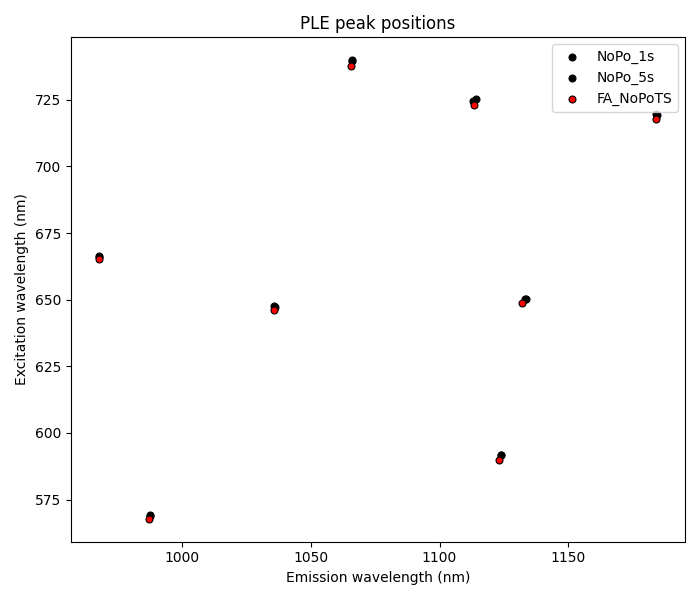

In [19]:
%matplotlib widget
#NoPo_1s,
#NoPo_5s,

#H2O,

#FAH2O_NopoBSa,
#FAH2O_NopoBSb,
#FA_NoPoTS,
#FA_NoPoBS_1s,
#FA_NoPoBS_10s,
#FA_NoPoBS_20s

plot_PLE_peaks_overlay(
    [
            NoPo_1s,
            NoPo_5s,

            #FAH2O_NopoBSa,
            #FAH2O_NopoBSb,
            
            FA_NoPoTS,
            
            #FA_NoPoBS_1s,
            #FA_NoPoBS_10s,
            #FA_NoPoBS_20s
    ],
    reference=None,
    threshold=0.25,
    min_distance=15,
    n_peaks=8,
    #zoom_at = (1036,647,5)
    #zoom_at = (987,568,5),
    colors=['black', 'black','red']
)

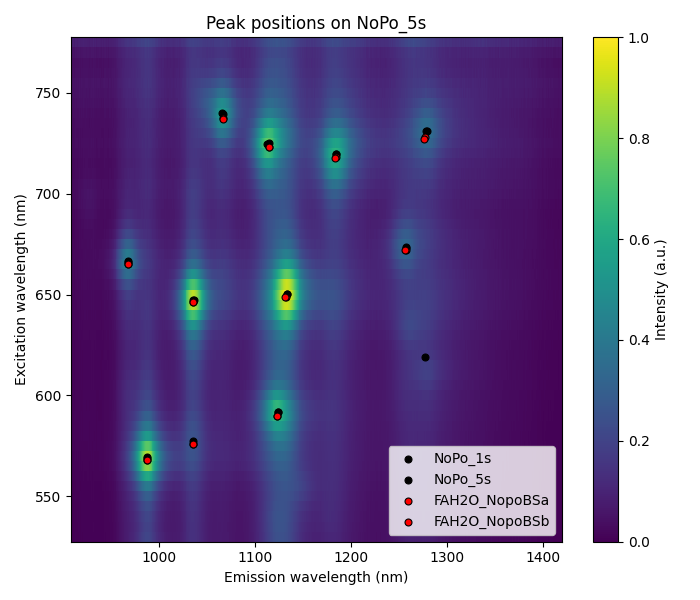

In [25]:
%matplotlib widget

#NoPo_1s,
#NoPo_5s,

#H2O,

#FAH2O_NopoBSa,
#FAH2O_NopoBSb,
#FA_NoPoTS,
#FA_NoPoBS_1s,
#FA_NoPoBS_10s,
#FA_NoPoBS_20s

plot_PLE_peaks_overlay(
    [
            NoPo_1s,
            NoPo_5s,

            #FAH2O_NopoBSa,
            #FAH2O_NopoBSb,
            
            FA_NoPoTS,
            
            #FA_NoPoBS_1s,
            #FA_NoPoBS_10s,
            #FA_NoPoBS_20s
    ],
    reference=NoPo_5s,
    threshold=0.1,
    min_distance=10,
    n_peaks=11,
    #zoom_at = (1036,647,5)
    #zoom_at = (987,568,5),
    colors=['black', 'black', 'red']
)

In [17]:
import h5py
import numpy as np

filename = "PLE_NoPos_Multiple.h5"

Alles = [
    
        NoPo_5s,
        
        FAH2O_NopoBSb,
        
        FA_NoPoTS,
        
        FA_NoPoBS_20s]

with h5py.File(filename, "w") as f:

    for SPECTRUM in Alles:

        grp = f.create_group(SPECTRUM.name)

        # -------------------------
        # Metadata
        # -------------------------
        grp.attrs["label"] = SPECTRUM.label
        grp.attrs["time"] = SPECTRUM.time
        grp.attrs["note"] = SPECTRUM.Note

        # -------------------------
        # Raw PLE map
        # -------------------------
        if SPECTRUM.PLE_WL is not None:

            ple = grp.create_group("PLE_WL")

            exc = ple.create_dataset(
                "excitation_nm",
                data=SPECTRUM.PLE_WL.index.values
            )

            em = ple.create_dataset(
                "emission_nm",
                data=SPECTRUM.PLE_WL.columns.values
            )

            intensity = ple.create_dataset(
                "intensity",
                data=SPECTRUM.PLE_WL.values
            )

            exc.make_scale("Excitation")
            em.make_scale("Emission")

            intensity.dims[0].attach_scale(exc)
            intensity.dims[1].attach_scale(em)

        # -------------------------
        # Corrected PLE map
        # -------------------------
        if SPECTRUM.PLE_corrected is not None:

            ple = grp.create_group("PLE_corrected")

            exc = ple.create_dataset(
                "excitation_nm",
                data=SPECTRUM.PLE_corrected.index.values
            )

            em = ple.create_dataset(
                "emission_nm",
                data=SPECTRUM.PLE_corrected.columns.values
            )

            intensity = ple.create_dataset(
                "intensity",
                data=SPECTRUM.PLE_corrected.values
            )

            exc.make_scale("Excitation")
            em.make_scale("Emission")

            intensity.dims[0].attach_scale(exc)
            intensity.dims[1].attach_scale(em)

        # -------------------------
        # R1 spectrum
        # -------------------------
        if SPECTRUM.R1 is not None:

            r1 = grp.create_group("R1")

            r1.create_dataset(
                "excitation_nm",
                data=SPECTRUM.R1.index.values
            )

            r1.create_dataset(
                "intensity",
                data=SPECTRUM.R1["Int"].values
            )

        # -------------------------
        # XYZ data
        # -------------------------
        if SPECTRUM.XYZ_df is not None:

            xyz = grp.create_group("XYZ")

            xyz.create_dataset(
                "Em_nm",
                data=SPECTRUM.XYZ_df["Em"].values
            )

            xyz.create_dataset(
                "Exc_nm",
                data=SPECTRUM.XYZ_df["Exc"].values
            )

            xyz.create_dataset(
                "Intensity",
                data=SPECTRUM.XYZ_df["Int"].values
            )

print(f"Saved {len(Alles)} measurements to {filename}")

Saved 4 measurements to PLE_NoPos_Multiple.h5


In [18]:
import h5py
import matplotlib.pyplot as plt

filename = "PLE_NoPos.h5"

with h5py.File(filename, "r") as f:
    excitation = f["PLE_WL"]["excitation_nm"][:]
    emission = f["PLE_WL"]["emission_nm"][:]
    intensity = f["PLE_WL"]["intensity"][:]

# Plot PLE map with correct physical axes
plt.figure(figsize=(8, 6))

plt.pcolormesh(
    emission,          # X axis: emission wavelength
    excitation,        # Y axis: excitation wavelength
    intensity,
    shading="auto",
    cmap="viridis",
    vmin=0,
    vmax=100
)

plt.xlabel("Emission wavelength (nm)")
plt.ylabel("Excitation wavelength (nm)")
plt.colorbar(label="Intensity (a.u.)")

plt.tight_layout()
plt.show()

FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = 'PLE_NoPos.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)